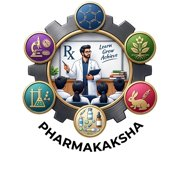

# BP604T · Unit III — AI in Drug Product Design and Performance
**Pharmakaksha · Learn · Grow · Achieve**
*AI applications in Pharmaceutical Sciences · B.Pharm Semester VI · PCI NEP 2020*

This notebook contains every example and demo from the Unit III study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit3_AI_in_Drug_Product_Design.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit3_AI_in_Drug_Product_Design.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. Real drug names and structures are used only to show how the methods work. The models are for learning AI methods only. They are not quality-control, regulatory or clinical tools.

## 3.1 Formulation variables
A formulation scientist changes **inputs** (composition and process settings) and measures **responses** (quality attributes).

| Inputs (factors) | Responses |
|---|---|
| binder % (e.g. PVP K30) | hardness (kp) |
| superdisintegrant % (e.g. croscarmellose sodium) | disintegration time (min) |
| lubricant % (e.g. magnesium stearate) | % drug dissolved at 30 min |
| compression force (kN) | friability, weight variation |

`tablet_formulations.csv` holds 60 fictional trial batches of an immediate-release tablet.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
tab = load("tablet_formulations.csv")
factors = ["binder_pct", "disintegrant_pct", "lubricant_pct", "compression_kN"]
responses = ["hardness_kp", "disintegration_min", "dissolved_30min_pct"]
print(tab.shape)
tab.head()

In [ ]:
# How does each factor relate to each response?
tab[factors + responses].corr().loc[factors, responses].round(2)

## 3.2 ML for formulation optimisation
Step 1: learn a model for each response from the 60 batches. Step 2: let the computer try thousands of **virtual formulations** and keep the ones that meet the targets. We compare a quadratic (response-surface) model with a random forest using 5-fold cross-validation.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(5, shuffle=True, random_state=0)
rsm = lambda: make_pipeline(PolynomialFeatures(2), LinearRegression())     # response-surface model
for r in responses:
    a = cross_val_score(rsm(), tab[factors], tab[r], cv=cv, scoring="r2").mean()
    b = cross_val_score(RandomForestRegressor(300, random_state=0), tab[factors], tab[r], cv=cv, scoring="r2").mean()
    print(f"{r:22s} quadratic CV R² = {a:.2f}   random forest CV R² = {b:.2f}")

In [ ]:
# Fit one quadratic model per response on all 60 batches
models = {r: rsm().fit(tab[factors], tab[r]) for r in responses}

# 20,736 virtual formulations inside the tested ranges
g = np.meshgrid(np.linspace(2, 6, 12), np.linspace(1, 5, 12), np.linspace(0.25, 2, 12), np.linspace(8, 20, 12))
virtual = pd.DataFrame({f: v.ravel() for f, v in zip(factors, g)})
for r in responses:
    virtual[r] = models[r].predict(virtual[factors])

# Targets: hardness 6–8 kp, disintegration ≤ 3 min, ≥ 90% dissolved at 30 min
ok = virtual[virtual["hardness_kp"].between(6, 8) & (virtual["disintegration_min"] <= 3) & (virtual["dissolved_30min_pct"] >= 90)]
print(len(virtual), "virtual formulations,", len(ok), "meet all three targets")
# Stay away from the edges of the tested ranges (robustness), then prefer the least superdisintegrant (cost)
robust = ok[ok["binder_pct"].between(2.5, 5.5) & ok["lubricant_pct"].between(0.5, 1.75) & ok["compression_kN"].between(10, 18)]
print(len(robust), "of them are away from the edges of the tested ranges")
best = robust.sort_values(["disintegrant_pct", "dissolved_30min_pct"], ascending=[True, False]).head(5)
best.round(2)

In [ ]:
# Design space picture: predicted % dissolved vs lubricant and disintegrant (binder 4%, 14 kN)
lub = np.linspace(0.25, 2, 60); dis = np.linspace(1, 5, 60)
L, D = np.meshgrid(lub, dis)
grid = pd.DataFrame({"binder_pct": 4.0, "disintegrant_pct": D.ravel(), "lubricant_pct": L.ravel(), "compression_kN": 14.0})
Z = models["dissolved_30min_pct"].predict(grid[factors]).reshape(L.shape)
plt.figure(figsize=(7.5, 5))
cs = plt.contourf(L, D, Z, levels=np.arange(70, 101, 2.5), cmap="YlGn")
plt.colorbar(cs, label="% dissolved at 30 min")
plt.contour(L, D, Z, levels=[90], colors="#E07A2E", linewidths=2.5)
plt.xlabel("Magnesium stearate (%)"); plt.ylabel("Croscarmellose sodium (%)")
plt.title("Predicted dissolution (orange line = 90% target)"); plt.show()

## 3.3 Solubility and bioavailability: choosing the polymer
`solid_dispersions.csv`: 48 fictional solid dispersions of a poorly soluble (BCS class II) drug, made with three polymers at different drug:polymer ratios and surfactant levels. Responses: solubility (µg/mL) and bioavailability (AUC, ng·h/mL). Polymer type is a **category**, so we one-hot encode it. Solubility spans a wide range, so we model **log₁₀(solubility)**.

In [ ]:
sd = load("solid_dispersions.csv")
print(sd.groupby("polymer")["solubility_ug_ml"].median().round(1))
Xs = pd.get_dummies(sd[["polymer"]], dtype=int).drop(columns="polymer_PVP K30")   # PVP K30 = reference
Xs["log_ratio"] = np.log10(sd["drug_polymer_ratio"])
Xs["surfactant_pct"] = sd["surfactant_pct"]
ys = np.log10(sd["solubility_ug_ml"])
m_sol = LinearRegression().fit(Xs, ys)
print("R² =", round(m_sol.score(Xs, ys), 2))
print(pd.Series(m_sol.coef_, index=Xs.columns).round(2))

In [ ]:
# Predict solubility for each polymer at 1:5, 1% surfactant
new = pd.DataFrame({"polymer_HPMC E5": [0, 1, 0], "polymer_Soluplus": [0, 0, 1],
                    "log_ratio": np.log10(5), "surfactant_pct": 1.0}, index=["PVP K30", "HPMC E5", "Soluplus"])
print((10 ** m_sol.predict(new[Xs.columns])).round(1))

In [ ]:
# Does more solubility mean more bioavailability? Fit log AUC vs log solubility
b = np.polyfit(np.log10(sd["solubility_ug_ml"]), np.log10(sd["auc_ng_h_ml"]), 1)
print("log AUC = %.2f + %.2f × log solubility" % (b[1], b[0]))
plt.figure(figsize=(7, 4.5))
for p, c in [("PVP K30", "#17725C"), ("HPMC E5", "#7A5195"), ("Soluplus", "#E07A2E")]:
    d = sd[sd["polymer"] == p]
    plt.scatter(d["solubility_ug_ml"], d["auc_ng_h_ml"], color=c, label=p)
xs = np.logspace(np.log10(sd["solubility_ug_ml"].min()), np.log10(sd["solubility_ug_ml"].max()), 50)
plt.plot(xs, 10 ** (b[1] + b[0] * np.log10(xs)), color="#12303A", linestyle="--")
plt.xscale("log"); plt.yscale("log"); plt.xlabel("Solubility (µg/mL)"); plt.ylabel("AUC (ng·h/mL)")
plt.title("Bioavailability rises with solubility, but less than proportionally"); plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

## 3.4 Drug-release modelling
`release_profiles.csv`: % released over 12 h from matrix tablets with 10%, 20% and 30% HPMC. We fit the classic release models:

| Model | Equation | Mechanism |
|---|---|---|
| Zero order | Q = k₀·t | constant rate |
| First order | Q = 100·(1 − e^(−k₁t)) | rate ∝ drug remaining |
| Higuchi | Q = k_H·√t | diffusion from a matrix |
| Korsmeyer–Peppas | Q = k·tⁿ (first 60% released) | n tells the mechanism |

In [ ]:
from scipy.optimize import curve_fit
rel = load("release_profiles.csv")
models_rel = {
    "Zero order":       lambda t, k: k * t,
    "First order":      lambda t, k: 100 * (1 - np.exp(-k * t)),
    "Higuchi":          lambda t, k: k * np.sqrt(t),
    "Korsmeyer–Peppas": lambda t, k, n: k * t ** n,
}
def r2(y, p):
    return 1 - np.sum((y - p) ** 2) / np.sum((y - np.mean(y)) ** 2)

rows = []
for hp, d in rel.groupby("hpmc_pct"):
    t, q = d["time_h"].values, d["released_pct"].values
    row = {"HPMC %": hp}
    for name, f in models_rel.items():
        mask = q <= 60 if name == "Korsmeyer–Peppas" else np.ones_like(q, bool)
        p0 = [10, 0.5] if name == "Korsmeyer–Peppas" else [0.1 if name == "First order" else 10]
        par, _ = curve_fit(f, t[mask], q[mask], p0=p0, maxfev=10000)
        row[name] = round(r2(q[mask], f(t[mask], *par)), 3)
        if name == "Korsmeyer–Peppas":
            row["k (KP)"], row["n"] = round(par[0], 2), round(par[1], 2)
    rows.append(row)
fits = pd.DataFrame(rows).set_index("HPMC %")
fits

In [ ]:
plt.figure(figsize=(8, 5))
tt = np.linspace(0, 12, 100)
for (hp, d), c in zip(rel.groupby("hpmc_pct"), ["#E07A2E", "#17725C", "#12303A"]):
    plt.scatter(d["time_h"], d["released_pct"], color=c, label=f"HPMC {hp}%")
    k, n = fits.loc[hp, "k (KP)"], fits.loc[hp, "n"]
    plt.plot(tt, np.minimum(k * tt ** n, 100), color=c)
plt.xlabel("Time (h)"); plt.ylabel("Drug released (%)")
plt.title("More HPMC → slower release (lines: Korsmeyer–Peppas fits)"); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [ ]:
# Learn how the release constant depends on HPMC %, then predict a new 25% HPMC matrix
lk = np.polyfit(fits.index, np.log(fits["k (KP)"]), 1)
n_avg = fits["n"].mean()
k25 = np.exp(np.polyval(lk, 25))
t50 = (50 / k25) ** (1 / n_avg)
print(f"Predicted for 25% HPMC: k = {k25:.1f}, t50 = {t50:.1f} h, released at 8 h = {min(k25 * 8 ** n_avg, 100):.0f}%")

## 3.5 Stability and degradation trends
`stability_stress.csv`: assay (% of label claim) of a fictional product stored at 40, 50 and 60 °C for 12 weeks. For **first-order** degradation, ln(assay) falls in a straight line with time; the slope is −k. The **Arrhenius equation** links k to temperature: ln k = ln A − Ea/(R·T).

In [ ]:
st = load("stability_stress.csv")
st["month"] = st["week"] / 4.345
ks = {}
for T, d in st.groupby("temp_c"):
    slope = np.polyfit(d["month"], np.log(d["assay_pct"]), 1)[0]
    ks[T] = -slope
ks = pd.Series(ks, name="k (per month)")
print(ks.round(4))

invT = 1 / (ks.index + 273.15)
fit = np.polyfit(invT, np.log(ks.values), 1)
Ea = -fit[0] * 8.314 / 1000
k_25 = np.exp(np.polyval(fit, 1 / 298.15))
print(f"Activation energy Ea = {Ea:.0f} kJ/mol")
print(f"Predicted k at 25 °C = {k_25:.5f} per month")
print(f"Predicted time to 95% (t95) = {np.log(100 / 95) / k_25:.1f} months;  t90 = {np.log(100 / 90) / k_25:.1f} months")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for (T, d), c in zip(st.groupby("temp_c"), ["#17725C", "#E07A2E", "#8C2D19"]):
    ax[0].plot(d["week"], d["assay_pct"], marker="o", color=c, label=f"{T} °C")
ax[0].set_xlabel("Week"); ax[0].set_ylabel("Assay (%)"); ax[0].set_title("Degradation at high temperature"); ax[0].legend(); ax[0].grid(alpha=0.3)
xs = np.linspace(1 / 333.15, 1 / 298.15, 20)
ax[1].scatter(1000 * invT, np.log(ks.values), color="#12303A", zorder=3, label="Measured k")
ax[1].plot(1000 * xs, np.polyval(fit, xs), color="#E07A2E", linestyle="--", label="Arrhenius line")
ax[1].scatter([1000 / 298.15], [np.log(k_25)], color="#E07A2E", marker="*", s=200, zorder=3, label="25 °C (extrapolated)")
ax[1].set_xlabel("1000 / T (K⁻¹)"); ax[1].set_ylabel("ln k"); ax[1].set_title("Arrhenius plot"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3.6 Shelf-life estimation
`stability_longterm.csv`: three batches at 25 °C/60% RH (ICH long-term) tested to 24 months. Following **ICH Q1E**, the shelf life is the time at which the **one-sided 95% lower confidence limit** of the mean regression line meets the specification (here 95.0% of label claim). We pool the three batches.

In [ ]:
from scipy import stats
lt = load("stability_longterm.csv")
x, yv = lt["month"].values, lt["assay_pct"].values
n = len(x); slope, intercept = np.polyfit(x, yv, 1)
resid = yv - (intercept + slope * x); s = np.sqrt(np.sum(resid ** 2) / (n - 2))
tcrit = stats.t.ppf(0.95, n - 2)
months = np.linspace(0, 48, 481)
lower = intercept + slope * months - tcrit * s * np.sqrt(1 / n + (months - x.mean()) ** 2 / np.sum((x - x.mean()) ** 2))
crossing = months[np.argmax(lower < 95.0)]
print(f"Assay = {intercept:.2f} {slope:+.3f} × month   (pooled, n = {n})")
print(f"Lower 95% confidence limit reaches 95.0% at {crossing:.1f} months")
print("ICH Q1E allows extrapolation to at most 2 × 24 months, and no more than 12 months beyond the data → 36 months maximum")

In [ ]:
plt.figure(figsize=(8, 5))
for (bch, d), c in zip(lt.groupby("batch"), ["#17725C", "#7A5195", "#12303A"]):
    plt.scatter(d["month"], d["assay_pct"], color=c, label=bch)
plt.plot(months, intercept + slope * months, color="#12303A")
plt.plot(months, lower, color="#E07A2E", linestyle="--", label="Lower 95% confidence limit")
plt.axhline(95, color="#8C2D19", linestyle=":", label="Specification 95.0%")
plt.axvline(crossing, color="grey", linestyle=":")
plt.xlabel("Month"); plt.ylabel("Assay (% label claim)"); plt.ylim(92, 102)
plt.title(f"Shelf-life estimate: {crossing:.1f} months"); plt.legend(loc="lower left"); plt.grid(alpha=0.3); plt.show()

## 3.7 Limits of extrapolation
A model only knows the range it was trained on. Watch what two models do when asked about **month 36**, beyond the 24 months of data.

In [ ]:
rf_st = RandomForestRegressor(n_estimators=300, random_state=0).fit(lt[["month"]], lt["assay_pct"])
lin_st = LinearRegression().fit(lt[["month"]], lt["assay_pct"])
future = pd.DataFrame({"month": [12, 24, 36, 48]})
print(pd.DataFrame({"month": future["month"], "linear": lin_st.predict(future).round(2),
                    "random forest": rf_st.predict(future).round(2)}).to_string(index=False))

The random forest predicts the **same value** at 24, 36 and 48 months: tree models cannot extrapolate, so they would wrongly suggest the product stops degrading. The linear model continues the trend, but only because we *assume* the trend stays linear. Arrhenius extrapolation also assumes the same degradation mechanism at every temperature.

## Worked example: choosing a formulation and a shelf life
Combine the unit: pick the cheapest formulation that meets the targets, predict its performance, and state the supported shelf life.

In [ ]:
choice = best.iloc[0]
print("Chosen formulation:")
print(choice[factors].round(2).to_string())
print(f"Predicted: hardness {choice['hardness_kp']:.1f} kp, disintegration {choice['disintegration_min']:.1f} min, "
      f"{choice['dissolved_30min_pct']:.0f}% dissolved at 30 min")
print(f"Shelf life supported by the 24-month data: {min(np.floor(crossing / 6) * 6, 36):.0f} months "
      f"(statistical estimate {crossing:.1f} months, rounded down)")

## Quick check
A random forest trained on 0–24 months of stability data predicts the same assay at 36 months as at 24 months. Does that mean the product is stable after 24 months? Decide, then run the cell.

In [ ]:
print("No. Tree models cannot extrapolate: outside the training range they repeat the last known value.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Which single factor has the strongest correlation with `disintegration_min`? Is the relationship positive or negative?

**2.** Change the targets in section 3.2 to hardness 5–7 kp, disintegration ≤ 2 min and ≥ 92% dissolved. How many virtual formulations pass?

**3.** Fit the Higuchi model to the 20% HPMC profile only. What is k_H?

**4.** Repeat the shelf-life calculation with a specification of 96.0%. What shelf life do you get?

---
## Solutions

In [ ]:
# 1
c = tab[factors].corrwith(tab["disintegration_min"])
print(c.round(2)); print("Strongest:", c.abs().idxmax())

In [ ]:
# 2
ok2 = virtual[virtual["hardness_kp"].between(5, 7) & (virtual["disintegration_min"] <= 2) & (virtual["dissolved_30min_pct"] >= 92)]
print(len(ok2), "formulations pass")

In [ ]:
# 3
d20 = rel[rel["hpmc_pct"] == 20]
kh, _ = curve_fit(lambda t, k: k * np.sqrt(t), d20["time_h"], d20["released_pct"])
print("k_H =", round(kh[0], 2), "% per √h")

In [ ]:
# 4
print("Shelf life:", months[np.argmax(lower < 96.0)], "months")

---
**Next:** Unit IV — AI in Process Monitoring and Production. Pharmakaksha · Learn · Grow · Achieve